# Color Evolution Figure
Same plot as your original `ax2` — set up so it's easy to add more comparison tracks (additional CSVs / lines) going forward.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
from astroquery.vizier import Vizier

## Compute g-r color from ZTF forced photometry

In [2]:
file = "/Users/ayannamann/Downloads/forcedphotometry_req00450494_lc.txt"

df1 = pd.read_csv(file, sep='\s+', comment='#')

# remove commas from column names
df1.columns = df1.columns.str.replace(',', '')

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/08/66vd8k6x5yjf6_d8qzw1479m0000gn/T/ipykernel_55534/2815290837.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df1 = pd.read_csv(file, sep='\s+', comment='#')


In [3]:
flux = df1['forcediffimflux']
fluxerr = df1['forcediffimfluxunc']
zp = df1['zpdiff']

mag = zp - 2.5*np.log10(flux)
magerr = 1.0857 * fluxerr / np.abs(flux)

df1['mag'] = mag
df1['magerr'] = magerr

/Users/ayannamann/1stYearProject/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
df1 = df1[magerr < .33]

In [5]:
g = df1[df1['filter'] == 'ZTF_g']
r = df1[df1['filter'] == 'ZTF_r']

gr_time = []
gr_color = []
gr_err = []

for _, g_row in g.iterrows():

    dt = np.abs(r['jd'] - g_row['jd'])
    idx = np.argmin(dt)

    if dt.iloc[idx] < 1:  # change this for range of time (was .5 to start)

        r_row = r.iloc[idx]

        color = g_row['mag'] - r_row['mag']
        err = np.sqrt(g_row['magerr']**2 + r_row['magerr']**2)

        gr_time.append(g_row['jd'])
        gr_color.append(color)
        gr_err.append(err)

gr_time = np.array(gr_time)
gr_color = np.array(gr_color)
gr_err = np.array(gr_err)

r_peak_jd = r.loc[r['mag'].idxmin(), 'jd']
time_since_peak = gr_time - r_peak_jd

## Load comparison tracks

`comparison_data` holds the published light curve photometry for each comparison
transient. For each one we compute a g-r color curve the same way we did for our
own data: matching each g-band point to the nearest r-band point within `max_dt`
days and differencing the magnitudes.

Add a new transient by giving it its own data-reading block below (following the
same pattern), then adding its `(time, color, err)` result to `loaded_tracks`.

In [7]:
# def load_track(path):
#     """Load a 2-column (x, y) CSV and sort by x so the line connects properly."""
#     df = pd.read_csv(path, header=None)
#     df = df.sort_values(by=0)
#     return df[0].to_numpy(), df[1].to_numpy()

# # Kishalay comparison data (scatter, not a connected line) — stays as a digitized CSV
# x_extra, y_extra = load_track("/Users/ayannamann/Downloads/Default Dataset.csv")

### `create_color` helper

Matches each point in band 1 to the nearest-in-time point in band 2 (within
`max_dt` days) and returns the time, color, and propagated error — same logic
as the g-r matching already used for our own ZTF photometry above.

In [8]:
def create_color(t1, m1, e1, t2, m2, e2, max_dt=1.0):
    """
    Match band-1 points to the nearest band-2 point in time (within max_dt days)
    and return (time, color = m1 - m2, propagated error).
    """
    t1 = np.asarray(t1, dtype=float)
    m1 = np.asarray(m1, dtype=float)
    e1 = np.asarray(e1, dtype=float)
    t2 = np.asarray(t2, dtype=float)
    m2 = np.asarray(m2, dtype=float)
    e2 = np.asarray(e2, dtype=float)

    times, colors, errs = [], [], []

    for ti, mi, ei in zip(t1, m1, e1):
        dt = np.abs(t2 - ti)
        idx = np.argmin(dt)

        if dt[idx] < max_dt:
            times.append(ti)
            colors.append(mi - m2[idx])
            errs.append(np.sqrt(ei**2 + e2[idx]**2))

    order = np.argsort(times)
    return np.array(times)[order], np.array(colors)[order], np.array(errs)[order]

### AT 2018hso (Vizier J/A+A/632/L6/)

In [15]:
filename = '/Users/ayannamann/Downloads/AT2018hso_lc.dat'
data = ascii.read(filename, format='cds', fill_values=[('-', '0'), ('', '0')])

mjd = data['MJD']
rmag = data['rmag']
rmagerr = data['e_rmag'].astype('float')
rdets = (rmagerr > 0)
rmjdpeak = mjd[rdets][np.argmin(rmag[rdets])]

gmag = data['gmag']
gmagerr = data['e_gmag'].astype('float')
gdets = (gmagerr > 0)

phase = mjd - rmjdpeak

rdettimes = np.array(phase[rdets])
rdetmags = rmag[rdets]
rdetmagerrs = rmagerr[rdets]
gdettimes = np.array(phase[gdets])
gdetmags = gmag[gdets]
gdetmagerrs = gmagerr[gdets]

at2018hso_time, at2018hso_gr, at2018hso_grerr = create_color(
    gdettimes, gdetmags, gdetmagerrs,
    rdettimes, rdetmags, rdetmagerrs
)

### AT 2019zhd

In [16]:
filename = '/Users/ayannamann/Downloads/AT2019zhd_lc.dat'
data = ascii.read(filename, format='cds', fill_values=[('-', '0'), ('', '0')])

mjd = data['MJD']
rmag = data['rmag']
rmagerr = data['e_rmag'].astype('float')
rdets = (rmagerr > 0)
rmjdpeak = mjd[rdets][np.argmin(rmag[rdets])]

gmag = data['gmag']
gmagerr = data['e_gmag'].astype('float')
gdets = (gmagerr > 0)

phase = mjd - rmjdpeak

rdettimes = np.array(phase[rdets])
rdetmags = rmag[rdets]
rdetmagerrs = rmagerr[rdets]
gdettimes = np.array(phase[gdets])
gdetmags = gmag[gdets]
gdetmagerrs = gmagerr[gdets]

at2019zhd_time, at2019zhd_gr, at2019zhd_grerr = create_color(
    gdettimes, gdetmags, gdetmagerrs,
    rdettimes, rdetmags, rdetmagerrs
)

### AT 2020kog

In [22]:
filename = '/Users/ayannamann/Downloads/AT2020kog_lc.dat'
data = ascii.read(filename)

mjd = data['MJD']

rmag = data['rmag']
rmagerr = data['e_rmag'].astype('float')
rdets = (rmagerr > 0)
rmjdpeak = mjd[rdets][np.argmin(rmag[rdets])]

gmag = data['gmag']
gmagerr = data['e_gmag'].astype('float')
gdets = (gmagerr > 0)

imag = data['imag']
imagerr = data['e_imag'].astype('float')
idets = (imagerr > 0)

phase = mjd - rmjdpeak

rdettimes = np.array(phase[rdets])
rdetmags = rmag[rdets].astype(float)
rdetmagerrs = rmagerr[rdets].astype(float)
gdettimes = np.array(phase[gdets])
gdetmags = gmag[gdets].astype(float)
gdetmagerrs = gmagerr[gdets].astype(float)

at2020kog_time, at2020kog_gr, at2020kog_grerr = create_color(
    gdettimes, gdetmags, gdetmagerrs,
    rdettimes, rdetmags, rdetmagerrs
)

### AT 2017jfs

In [23]:
filename = '/Users/ayannamann/Downloads/AT2017jfs_lc.dat'
data = ascii.read(filename, format='cds')

mjd = data['MJD']
rmag = data['rmag']
rmagerr = data['e_rmag'].astype('float')
rdets = (rmagerr > 0)
rmjdpeak = mjd[rdets][np.argmin(rmag[rdets])]

gmag = data['gmag']
gmagerr = data['e_gmag'].astype('float')
gdets = (gmagerr > 0)

phase = mjd - rmjdpeak

rdettimes = np.array(phase[rdets])
rdetmags = rmag[rdets]
rdetmagerrs = rmagerr[rdets]
gdettimes = np.array(phase[gdets])
gdetmags = gmag[gdets]
gdetmagerrs = gmagerr[gdets]

at2017jfs_time, at2017jfs_gr, at2017jfs_grerr = create_color(
    gdettimes, gdetmags, gdetmagerrs,
    rdettimes, rdetmags, rdetmagerrs
)

### Collect into `loaded_tracks`

Each entry is `label: (time, color, error, plot_color)`. Add new transients here
once you've computed their `(time, gr, grerr)` above.

In [24]:
loaded_tracks = {
    "AT 2018hso": (at2018hso_time, at2018hso_gr, at2018hso_grerr, "black"),
    "AT 2019zhd": (at2019zhd_time, at2019zhd_gr, at2019zhd_grerr, "magenta"),
    "AT 2020kog": (at2020kog_time, at2020kog_gr, at2020kog_grerr, "darkorange"),
    "AT 2017jfs": (at2017jfs_time, at2017jfs_gr, at2017jfs_grerr, "steelblue"),
    # Add more comparison tracks here, e.g.:
    # "AT 2020kog": (at2020kog_time, at2020kog_gr, at2020kog_grerr, "c"),
    # "N3437-2011-OT": (n3437_time, n3437_gr, n3437_grerr, "brown"),
}

## Color evolution plot

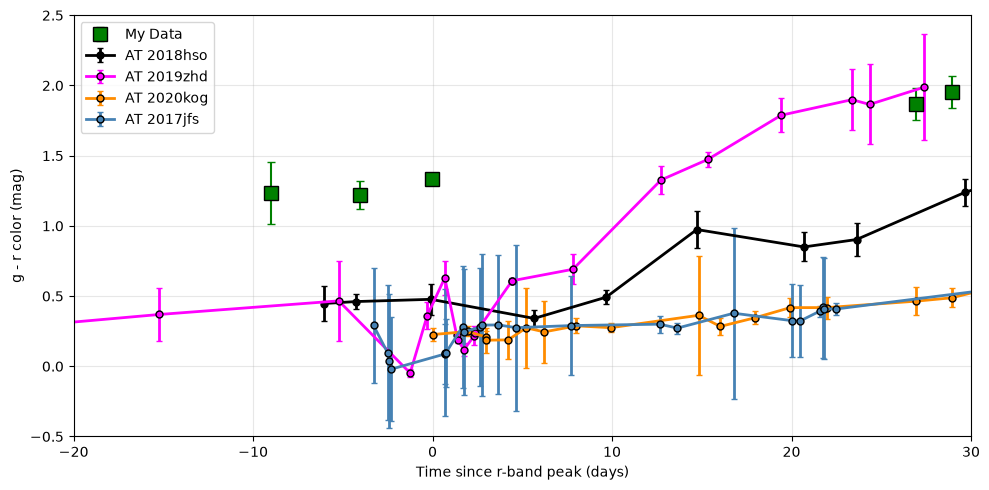

In [30]:
fig, ax2 = plt.subplots(figsize=(10, 5), dpi=100)

# -- My data --
ax2.errorbar(
    time_since_peak,
    gr_color,
    yerr=gr_err,
    fmt='s',
    color='green',
    markeredgecolor='black',
    markersize=10,
    capsize=3,
    linestyle='none',
    label="My Data"
)

# # -- Kishalay comparison data (scatter) --
# ax2.scatter(
#     x_extra,
#     y_extra,
#     marker='s',
#     color='red',
#     edgecolors='black',
#     s=100,
#     label="Kishalay Data"
# )

# -- Computed comparison tracks (lines with error bars) --
for label, (t, color_vals, err_vals, plot_color) in loaded_tracks.items():
    ax2.errorbar(
        t, color_vals, yerr=err_vals,
        color=plot_color,
        markeredgecolor='black',
        linestyle='-',
        linewidth=2,
        marker='o',
        markersize=5,
        capsize=2,
        label=label
    )

# -- Formatting --
ax2.set_xlabel("Time since r-band peak (days)")
ax2.set_ylabel("g - r color (mag)")
ax2.set_xlim(-20, 30)
ax2.set_ylim(-.5, 2.5)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("color_evolution_figure.pdf", bbox_inches="tight")
plt.show()